In [1]:
# importing spark session
from pyspark.sql import SparkSession

# data visualization modules 
import matplotlib.pyplot as plt
import plotly.express as px 

# pandas module 
import pandas as pd

# pyspark SQL functions 
from pyspark.sql.functions import col, when, count, udf

# pyspark data preprocessing modules
from pyspark.ml.feature import Imputer, StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder

# pyspark data modeling and model evaluation modules
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator


In [2]:
spark_session = \
  SparkSession.builder\
              .appName("Customer_Churn_Prediction")\
              .getOrCreate()

print(f"This cluster relies on Spark '{spark_session.version}'")

25/12/13 23:25:34 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
25/12/13 23:25:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/13 23:25:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


This cluster relies on Spark '3.5.4'


In [3]:
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key", "s3access")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key", "_s3access123$")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.path.style.access", "true")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.endpoint", "http://localhost:9000")

In [4]:
df_cx = spark_session.read.option("header", True).csv("s3a://customer-experience/bronze/customer_experience/2025/12/13/data.csv")
# The inferred schema can be visualized using the printSchema() method - definitely semi-structured data.
df_cx.printSchema()

25/12/13 23:25:47 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
25/12/13 23:25:48 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:2451)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

root
 |-- Churn: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- MonthlyCharges: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- Partner: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- SeniorCitizen: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- tenure: string (nullable = true)



In [5]:
type(df_cx)

pyspark.sql.dataframe.DataFrame

In [6]:
#Here we are replacing "NaN" string with Null
df_cx_clean = df_cx.na.replace("NaN", None)

In [7]:
df_cx_clean.show(4)

+-----+--------------+----------+----------------+---------------+--------------+----------------+------------+--------------+----------------+-------+--------------------+------------+-------------+---------------+-----------+-----------+------------+----------+------+------+
|Churn|      Contract|Dependents|DeviceProtection|InternetService|MonthlyCharges|   MultipleLines|OnlineBackup|OnlineSecurity|PaperlessBilling|Partner|       PaymentMethod|PhoneService|SeniorCitizen|StreamingMovies|StreamingTV|TechSupport|TotalCharges|customerID|gender|tenure|
+-----+--------------+----------+----------------+---------------+--------------+----------------+------------+--------------+----------------+-------+--------------------+------------+-------------+---------------+-----------+-----------+------------+----------+------+------+
|   No|Month-to-month|        No|              No|            DSL|         29.85|No phone service|         Yes|            No|             Yes|    Yes|    Electronic 

In [8]:
#Since the schema shows all columns as string we are converting columns with numeric values to double
cols_to_double = ["tenure", "MonthlyCharges", "TotalCharges"]

for c in cols_to_double:
    df_cx_clean = df_cx_clean.withColumn(c, col(c).cast("double"))

In [9]:
df_cx_clean.printSchema()

root
 |-- Churn: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- Partner: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- SeniorCitizen: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- tenure: double (nullable = true)



Get the data dimension

In [10]:
df_cx_clean.count()

7043

In [11]:
df_cx_clean.columns

['Churn',
 'Contract',
 'Dependents',
 'DeviceProtection',
 'InternetService',
 'MonthlyCharges',
 'MultipleLines',
 'OnlineBackup',
 'OnlineSecurity',
 'PaperlessBilling',
 'Partner',
 'PaymentMethod',
 'PhoneService',
 'SeniorCitizen',
 'StreamingMovies',
 'StreamingTV',
 'TechSupport',
 'TotalCharges',
 'customerID',
 'gender',
 'tenure']

In [12]:
len(df_cx_clean.columns)

21

Explortory Data Analysis : 

    1. Distribution analysis
    2. Correlation analysis
    3. Univariate analysis
    4. Finding missing values

In [13]:
#Column names with data types
df_cx_clean.dtypes

[('Churn', 'string'),
 ('Contract', 'string'),
 ('Dependents', 'string'),
 ('DeviceProtection', 'string'),
 ('InternetService', 'string'),
 ('MonthlyCharges', 'double'),
 ('MultipleLines', 'string'),
 ('OnlineBackup', 'string'),
 ('OnlineSecurity', 'string'),
 ('PaperlessBilling', 'string'),
 ('Partner', 'string'),
 ('PaymentMethod', 'string'),
 ('PhoneService', 'string'),
 ('SeniorCitizen', 'string'),
 ('StreamingMovies', 'string'),
 ('StreamingTV', 'string'),
 ('TechSupport', 'string'),
 ('TotalCharges', 'double'),
 ('customerID', 'string'),
 ('gender', 'string'),
 ('tenure', 'double')]

In [14]:
numerical_columns = [name for name,typ in df_cx_clean.dtypes if typ == "double"]
numerical_columns

['MonthlyCharges', 'TotalCharges', 'tenure']

In [15]:
categorical_columns = [name for name,typ in df_cx_clean.dtypes if typ == "string"]
categorical_columns

['Churn',
 'Contract',
 'Dependents',
 'DeviceProtection',
 'InternetService',
 'MultipleLines',
 'OnlineBackup',
 'OnlineSecurity',
 'PaperlessBilling',
 'Partner',
 'PaymentMethod',
 'PhoneService',
 'SeniorCitizen',
 'StreamingMovies',
 'StreamingTV',
 'TechSupport',
 'customerID',
 'gender']

In [16]:
df_cx_clean.select(numerical_columns).show(20)

+--------------+------------+------+
|MonthlyCharges|TotalCharges|tenure|
+--------------+------------+------+
|         29.85|       29.85|   1.0|
|         56.95|      1889.5|  34.0|
|         53.85|      108.15|   2.0|
|          42.3|     1840.75|  45.0|
|          70.7|      151.65|   2.0|
|         99.65|       820.5|   8.0|
|          89.1|      1949.4|  22.0|
|         29.75|       301.9|  10.0|
|         104.8|     3046.05|  28.0|
|         56.15|     3487.95|  62.0|
|         49.95|      587.45|  13.0|
|         18.95|       326.8|  16.0|
|        100.35|      5681.1|  58.0|
|         103.7|      5036.3|  49.0|
|         105.5|     2686.05|  25.0|
|        113.25|     7895.15|  69.0|
|         20.65|     1022.95|  52.0|
|         106.7|     7382.25|  71.0|
|          55.2|      528.35|  10.0|
|         90.05|      1862.9|  21.0|
+--------------+------------+------+
only showing top 20 rows



To visualize the data we need to convert from a distributed system (spark) to pandas

In [17]:
df = df_cx_clean.select(numerical_columns).toPandas()

Let's create a histogram to check the ditribution of our numerical data

/tmp/ipykernel_1468/3580938193.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax, bins = 20)


array([[<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>],
       [<Axes: title={'center': 'tenure'}>, <Axes: >]], dtype=object)

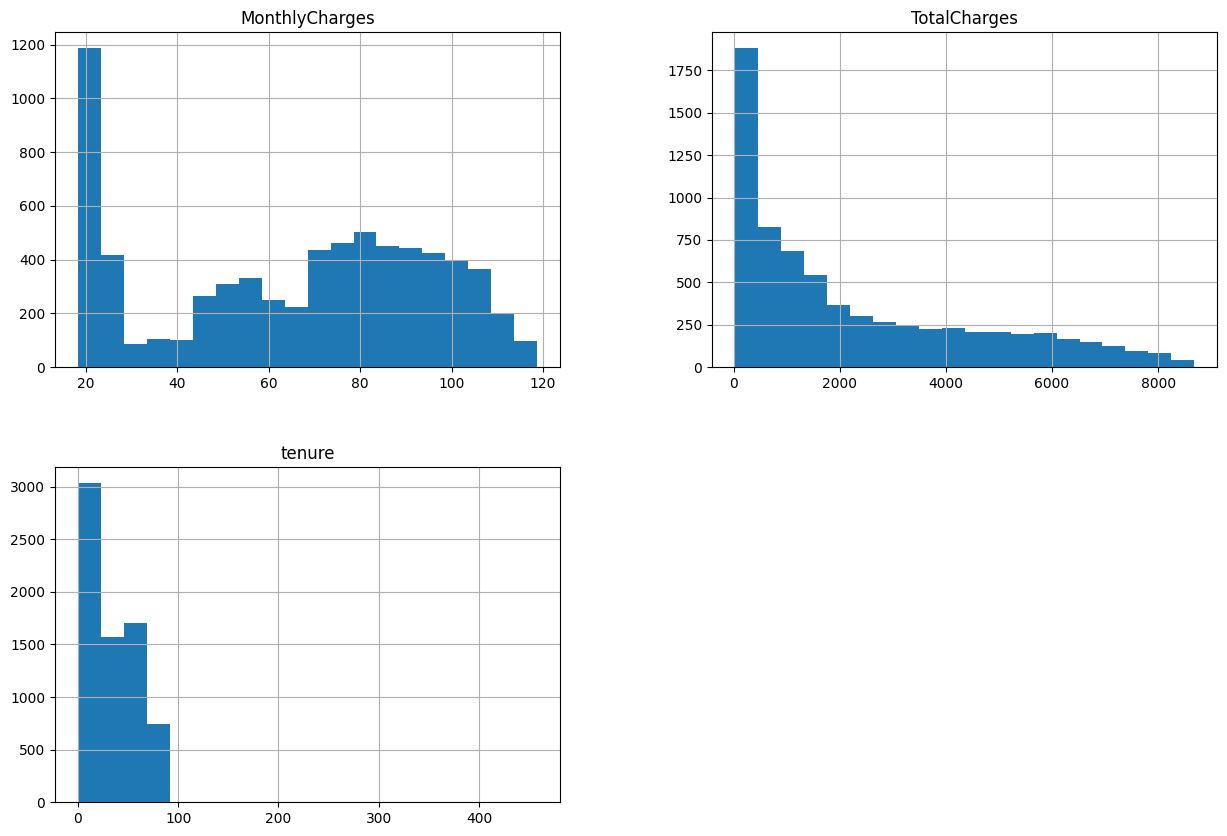

In [18]:
fig = plt.figure(figsize = (15,10))
ax = fig.gca()
df.hist(ax=ax, bins = 20)

In [19]:
#From the histogram we can see that there could be outliers in tenure
df.tenure.describe()

count    7043.000000
mean       32.435752
std        25.075228
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max       458.000000
Name: tenure, dtype: float64

Considering the mean is 32 months and we see the max as 458 months, it's clear that we have outliers and we will deal with them during preprocessing

In [20]:
#Lets generate the correlation matrix

df.corr()

,MonthlyCharges,TotalCharges,tenure
MonthlyCharges,1.000000,0.651065,0.243703
TotalCharges,0.651065,1.000000,0.806530
tenure,0.243703,0.806530,1.000000


In [21]:
#Lets check the unique value count for each categorical variables
for column in categorical_columns :
    df_cx_clean.groupby(column).count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5174|
|  Yes| 1869|
+-----+-----+

+--------------+-----+
|      Contract|count|
+--------------+-----+
|Month-to-month| 3875|
|      One year| 1473|
|      Two year| 1695|
+--------------+-----+

+----------+-----+
|Dependents|count|
+----------+-----+
|        No| 4933|
|       Yes| 2110|
+----------+-----+

+-------------------+-----+
|   DeviceProtection|count|
+-------------------+-----+
|                 No| 3095|
|                Yes| 2422|
|No internet service| 1526|
+-------------------+-----+

+---------------+-----+
|InternetService|count|
+---------------+-----+
|    Fiber optic| 3096|
|             No| 1526|
|            DSL| 2421|
+---------------+-----+

+----------------+-----+
|   MultipleLines|count|
+----------------+-----+
|No phone service|  682|
|              No| 3390|
|             Yes| 2971|
+----------------+-----+

+-------------------+-----+
|       OnlineBackup|count|
+-------------------+-----+
|           

+----------+-----+
|customerID|count|
+----------+-----+
|3668-QPYBK|    1|
|6234-RAAPL|    1|
|1894-IGFSG|    1|
|6982-SSHFK|    1|
|5859-HZYLF|    1|
|6479-OAUSD|    1|
|2592-YKDIF|    1|
|6718-BDGHG|    1|
|3195-TQDZX|    1|
|4248-QPAVC|    1|
|5668-MEISB|    1|
|5802-ADBRC|    1|
|2712-SYWAY|    1|
|2011-TRQYE|    1|
|7244-KXYZN|    1|
|0953-LGOVU|    1|
|3623-FQBOX|    1|
|3692-JHONH|    1|
|3528-HFRIQ|    1|
|7661-CPURM|    1|
+----------+-----+
only showing top 20 rows

+------+-----+
|gender|count|
+------+-----+
|Female| 3488|
|  Male| 3555|
+------+-----+



In [22]:
#Lets look at the null values in all of our dataframe columns
for column in df_cx_clean.columns:
    df_cx_clean.select(count(when(col(column).isNull(),column)).alias(column)).show()

+-----+
|Churn|
+-----+
|    0|
+-----+

+--------+
|Contract|
+--------+
|       0|
+--------+

+----------+
|Dependents|
+----------+
|         0|
+----------+

+----------------+
|DeviceProtection|
+----------------+
|               0|
+----------------+

+---------------+
|InternetService|
+---------------+
|              0|
+---------------+

+--------------+
|MonthlyCharges|
+--------------+
|             0|
+--------------+

+-------------+
|MultipleLines|
+-------------+
|            0|
+-------------+

+------------+
|OnlineBackup|
+------------+
|           0|
+------------+

+--------------+
|OnlineSecurity|
+--------------+
|             0|
+--------------+

+----------------+
|PaperlessBilling|
+----------------+
|               0|
+----------------+

+-------+
|Partner|
+-------+
|      0|
+-------+

+-------------+
|PaymentMethod|
+-------------+
|            0|
+-------------+

+------------+
|PhoneService|
+------------+
|           0|
+------------+

+-------------+
|

+-----------+
|TechSupport|
+-----------+
|          0|
+-----------+

+------------+
|TotalCharges|
+------------+
|          11|
+------------+

+----------+
|customerID|
+----------+
|         0|
+----------+

+------+
|gender|
+------+
|     0|
+------+

+------+
|tenure|
+------+
|     0|
+------+



<b>Data Preprocessing</b> :
    1. Handling missing values
    2. Handling outliers

In [23]:
#Missing values
col_with_missing_val = ["TotalCharges"]

In [24]:
imputer = Imputer(inputCols = col_with_missing_val, outputCols = col_with_missing_val).setStrategy("mean")

In [25]:
imputer = imputer.fit(df_cx_clean)
df_cx_clean = imputer.transform(df_cx_clean)

In [26]:
df_cx_clean.select(count(when(col("TotalCharges").isNull(),"TotalCharges")).alias("TotalCharges")).show()

+------------+
|TotalCharges|
+------------+
|           0|
+------------+



In [27]:
#Outliers
df_cx_clean.select("*").where(df_cx_clean.tenure > 100).show()

+-----+--------------+----------+----------------+---------------+--------------+-------------+------------+--------------+----------------+-------+----------------+------------+-------------+---------------+-----------+-----------+------------+----------+------+------+
|Churn|      Contract|Dependents|DeviceProtection|InternetService|MonthlyCharges|MultipleLines|OnlineBackup|OnlineSecurity|PaperlessBilling|Partner|   PaymentMethod|PhoneService|SeniorCitizen|StreamingMovies|StreamingTV|TechSupport|TotalCharges|customerID|gender|tenure|
+-----+--------------+----------+----------------+---------------+--------------+-------------+------------+--------------+----------------+-------+----------------+------------+-------------+---------------+-----------+-----------+------------+----------+------+------+
|   No|Month-to-month|        No|              No|            DSL|          75.3|           No|         Yes|            No|             Yes|     No|Electronic check|         Yes|         

In [28]:
print("Before we remive the outlier",df_cx_clean.count())
df_cx_clean = df_cx_clean.filter(df_cx_clean.tenure < 100)
print("After we remive the outlier",df_cx_clean.count())

Before we remive the outlier 7043
After we remive the outlier 7042


<b>Feature preparation :</b>
    1. Vector assembling
    2. Scaling numeric columns

In [29]:
numerical_vector_assembler = VectorAssembler(inputCols= numerical_columns, outputCol= "numerical_features_vector")

In [30]:
df_cx_clean = numerical_vector_assembler.transform(df_cx_clean)

In [31]:
df_cx_clean.select("numerical_features_vector").show(5)

+-------------------------+
|numerical_features_vector|
+-------------------------+
|        [29.85,29.85,1.0]|
|      [56.95,1889.5,34.0]|
|       [53.85,108.15,2.0]|
|      [42.3,1840.75,45.0]|
|        [70.7,151.65,2.0]|
+-------------------------+
only showing top 5 rows



In [32]:
#Numerical scaling

scaler = StandardScaler(inputCol="numerical_features_vector",outputCol="numerical_features_scaled",withMean=True,withStd=True)

df_cx_clean = scaler.fit(df_cx_clean).transform(df_cx_clean)

df_cx_clean.select(["numerical_features_vector","numerical_features_scaled"]).show(5)

+-------------------------+-------------------------+
|numerical_features_vector|numerical_features_scaled|
+-------------------------+-------------------------+
|        [29.85,29.85,1.0]|     [-1.1601185306298...|
|      [56.95,1889.5,34.0]|     [-0.2595446063316...|
|       [53.85,108.15,2.0]|     [-0.3625622877089...|
|      [42.3,1840.75,45.0]|     [-0.7463862296146...|
|        [70.7,151.65,2.0]|     [0.19738865784176...|
+-------------------------+-------------------------+
only showing top 5 rows



In [33]:
#Converting strings to numerics

categorical_columns_indexed = [name + "_Indexed" for name in categorical_columns]

indexer = StringIndexer(inputCols=categorical_columns, outputCols= categorical_columns_indexed )

df_cx_clean = indexer.fit(df_cx_clean).transform(df_cx_clean)

25/12/13 23:26:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

In [34]:
df_cx_clean.select("gender_Indexed").show(10)

+--------------+
|gender_Indexed|
+--------------+
|           1.0|
|           0.0|
|           0.0|
|           0.0|
|           1.0|
|           1.0|
|           0.0|
|           1.0|
|           1.0|
|           0.0|
+--------------+
only showing top 10 rows



In [35]:
categorical_columns_indexed.remove("Churn_Indexed")
categorical_columns_indexed.remove("customerID_Indexed")

In [36]:
categorical_vector_assembler = VectorAssembler(inputCols=categorical_columns_indexed, outputCol="categorical_features_vector")
df_cx_clean = categorical_vector_assembler.transform(df_cx_clean)
df_cx_clean.select("categorical_features_vector").show(5)

+---------------------------+
|categorical_features_vector|
+---------------------------+
|       (16,[3,4,5,8,10,1...|
|       (16,[0,2,3,6,7,9]...|
|       (16,[3,5,6,9],[1....|
|       (16,[0,2,3,4,6,7,...|
|            (16,[15],[1.0])|
+---------------------------+
only showing top 5 rows



In [37]:
final_vector_assembler = VectorAssembler(inputCols=["categorical_features_vector","numerical_features_scaled"],outputCol="final_features_vector")
df_cx_clean = final_vector_assembler.transform(df_cx_clean)

In [38]:
df_cx_clean.select(["final_features_vector","Churn_Indexed"]).show(5)

+---------------------+-------------+
|final_features_vector|Churn_Indexed|
+---------------------+-------------+
| (19,[3,4,5,8,10,1...|          0.0|
| (19,[0,2,3,6,7,9,...|          0.0|
| (19,[3,5,6,9,16,1...|          1.0|
| [2.0,0.0,1.0,1.0,...|          0.0|
| (19,[15,16,17,18]...|          1.0|
+---------------------+-------------+
only showing top 5 rows



<b>Model Training</b>

In [41]:
#Model training - Test Train split

train, test = df_cx_clean.randomSplit([0.7,0.3],seed = 100)

In [42]:
test.count()

2112

In [43]:
train.count()

4930

In [58]:
#Training decision tree

dt = DecisionTreeClassifier(featuresCol="final_features_vector",labelCol="Churn_Indexed",maxDepth=6)
model = dt.fit(train)

In [59]:
predictions_test = model.transform(test)
predictions_test.groupby(["Churn","prediction"]).count().show()

[Stage 1046:========================================================(1 + 0) / 1]

+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|  Yes|       0.0|  303|
|   No|       0.0| 1359|
|   No|       1.0|  180|
|  Yes|       1.0|  270|
+-----+----------+-----+



<b>Model Evaluation</b>

In [60]:

evaluator = BinaryClassificationEvaluator(labelCol= "Churn_Indexed")
auc_test = evaluator.evaluate(predictions_test,{evaluator.metricName : "areaUnderROC"})

In [61]:
auc_test

0.7888879817020414

In [62]:
predictions_train = model.transform(train)
auc_train = evaluator.evaluate(predictions_train,{evaluator.metricName : "areaUnderROC"})
auc_train

0.7876432373944299

In [54]:
def evaluate_dt(mode_params):
      test_accuracies = []
      train_accuracies = []

      for maxD in mode_params:
        # train the model based on the maxD
        decision_tree = DecisionTreeClassifier(featuresCol = 'final_features_vector', labelCol = 'Churn_Indexed', maxDepth = maxD)
        dtModel = decision_tree.fit(train)

        # calculating test error 
        predictions_test = dtModel.transform(test)
        evaluator = BinaryClassificationEvaluator(labelCol="Churn_Indexed")
        auc_test = evaluator.evaluate(predictions_test, {evaluator.metricName: "areaUnderROC"})
        # recording the accuracy 
        test_accuracies.append(auc_test)

        # calculating training error
        predictions_training = dtModel.transform(train)
        evaluator = BinaryClassificationEvaluator(labelCol="Churn_Indexed")
        auc_training = evaluator.evaluate(predictions_training, {evaluator.metricName: "areaUnderROC"})
        train_accuracies.append(auc_training)

      return(test_accuracies, train_accuracies)  

In [55]:
maxDepths = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
test_accs, train_accs = evaluate_dt(maxDepths)
print(train_accs)
print(test_accs)

[0.7813548907098256, 0.7967787086297451, 0.6945199275362319, 0.7771170087717512, 0.7876432373944299, 0.7603273821656915, 0.7658628088967705, 0.7453692025588237, 0.823110311054037, 0.8663871775141496, 0.8985004025764896, 0.9329589117185431, 0.9441215976341412, 0.9637647186720751, 0.9741022926476284, 0.9794140303851825, 0.9843487773225437, 0.9862148340093901, 0.9882780385182468]
[0.7734300848106305, 0.7889872052634981, 0.6678579163959281, 0.7647925320378705, 0.7888879817020414, 0.7259881816233429, 0.7312334225778394, 0.6950026478516114, 0.7073335850776835, 0.6983048079768939, 0.6928673568090611, 0.7146330372502259, 0.7042933751546471, 0.7022816883200829, 0.6847361276956208, 0.6839888325299059, 0.6824352750533823, 0.6807711541798067, 0.680279005314981]


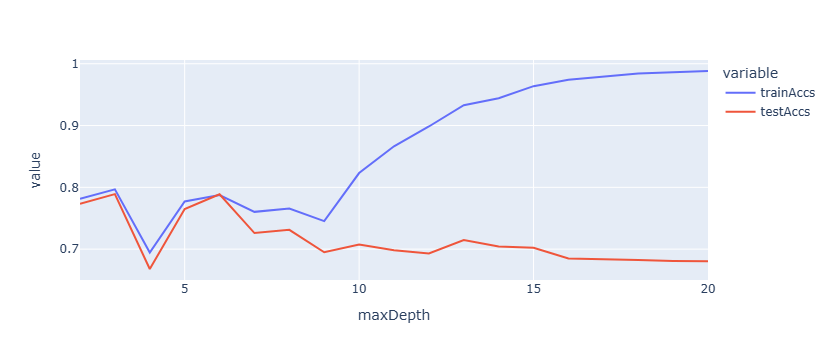

In [56]:
#Lets Visualize the results

df_check = pd.DataFrame()
df_check["maxDepth"]=maxDepths
df_check["trainAccs"]=train_accs
df_check["testAccs"]=test_accs

px.line(df_check,x="maxDepth",y=["trainAccs","testAccs"])

<b>Model deployment</b>

In [64]:
feature_importance = model.featureImportances
feature_importance

SparseVector(19, {0: 0.5161, 1: 0.0025, 3: 0.1398, 4: 0.009, 6: 0.0385, 9: 0.0324, 10: 0.0107, 11: 0.0032, 13: 0.0025, 14: 0.0029, 16: 0.0494, 17: 0.0087, 18: 0.1841})

In [66]:
scores = [score for i, score in enumerate(feature_importance)]
df = pd.DataFrame(scores, columns = ["score"],index = categorical_columns_indexed + numerical_columns)
df

,score
Contract_Indexed,0.516111
Dependents_Indexed,0.002529
DeviceProtection_Indexed,0.000000
InternetService_Indexed,0.139796
MultipleLines_Indexed,0.009046
OnlineBackup_Indexed,0.000000
OnlineSecurity_Indexed,0.038475
PaperlessBilling_Indexed,0.000000
Partner_Indexed,0.000000
PaymentMethod_Indexed,0.032430


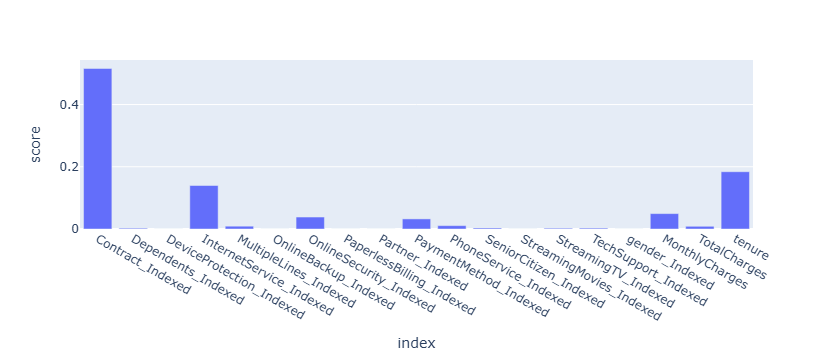

In [68]:
px.bar(df,y="score")

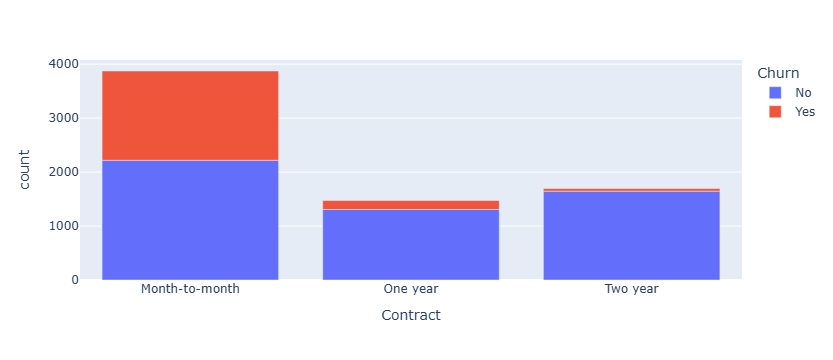

In [69]:
df = df_cx_clean.groupby(["Contract","Churn"]).count().toPandas()
px.bar(df,x="Contract",y="count",color = "Churn")